## Section 1: Import Libraries and Dataset

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Download NLTK resources
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


## Section 2: Load Text Data

We'll create a sample dataset with product reviews. In a real scenario, you would scrape reviews from Amazon or Flipkart.

In [5]:
# Create sample product reviews dataset
# In real scenario: df = pd.read_csv('reviews.csv')

sample_reviews = [
    {"review_text": "This product is amazing! Great quality and fast delivery.", "sentiment": 1},
    {"review_text": "Excellent product. Highly recommended for everyone.", "sentiment": 1},
    {"review_text": "Very disappointed with this purchase. Poor quality.", "sentiment": 0},
    {"review_text": "Not worth the price. Broke after one week.", "sentiment": 0},
    {"review_text": "Fantastic quality and great customer service!", "sentiment": 1},
    {"review_text": "Waste of money. Terrible product.", "sentiment": 0},
    {"review_text": "Absolutely love this item! Perfect for my needs.", "sentiment": 1},
    {"review_text": "Good product but delivery was very slow.", "sentiment": 0},
    {"review_text": "Outstanding quality and amazing features!", "sentiment": 1},
    {"review_text": "Horrible experience. Product stopped working.", "sentiment": 0},
    {"review_text": "Best purchase ever! Highly satisfied.", "sentiment": 1},
    {"review_text": "Disappointing quality. Expected much better.", "sentiment": 0},
    {"review_text": "Fantastic product for the price. Recommended!", "sentiment": 1},
    {"review_text": "Terrible quality and poor customer support.", "sentiment": 0},
    {"review_text": "Love everything about this product.", "sentiment": 1},
    {"review_text": "Worst purchase I have ever made.", "sentiment": 0},
    {"review_text": "Excellent value for money and great quality.", "sentiment": 1},
    {"review_text": "Not satisfied. Product does not work as described.", "sentiment": 0},
    {"review_text": "Amazing product with fantastic features.", "sentiment": 1},
    {"review_text": "Poor quality and bad customer service experience.", "sentiment": 0},
]

df = pd.DataFrame(sample_reviews)

print(f"Dataset shape: {df.shape}")
print(f"\nFirst few reviews:")
print(df.head())
print(f"\nDataset info:")
print(df.info())
print(f"\nSentiment distribution:")
print(df['sentiment'].value_counts())

Dataset shape: (20, 2)

First few reviews:
                                         review_text  sentiment
0  This product is amazing! Great quality and fas...          1
1  Excellent product. Highly recommended for ever...          1
2  Very disappointed with this purchase. Poor qua...          0
3         Not worth the price. Broke after one week.          0
4      Fantastic quality and great customer service!          1

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   review_text  20 non-null     object
 1   sentiment    20 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 452.0+ bytes
None

Sentiment distribution:
sentiment
1    10
0    10
Name: count, dtype: int64


## Section 3: Text Preprocessing

### Task 1: Preprocessing
- Convert text to lowercase
- Tokenization
- Remove punctuation
- Remove stopwords
- Lemmatization

In [6]:
# Define preprocessing function
def preprocess_text(text, remove_stopwords=True, lemmatize=True):
    """
    Comprehensive text preprocessing pipeline
    
    Steps:
    1. Convert to lowercase
    2. Remove punctuation
    3. Tokenization
    4. Remove stopwords (optional)
    5. Lemmatization (optional)
    """
    
    # Step 1: Convert to lowercase
    text = text.lower()
    
    # Step 2: Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Step 3: Tokenization
    tokens = word_tokenize(text)
    
    # Step 4: Remove stopwords
    if remove_stopwords:
        stop_words = set(stopwords.words('english'))
        tokens = [token for token in tokens if token not in stop_words and len(token) > 1]
    
    # Step 5: Lemmatization
    if lemmatize:
        lemmatizer = WordNetLemmatizer()
        tokens = [lemmatizer.lemmatize(token, pos='v') for token in tokens]
        tokens = [lemmatizer.lemmatize(token, pos='n') for token in tokens]
    
    return tokens

# Apply preprocessing to all reviews
df['preprocessed_tokens'] = df['review_text'].apply(
    lambda x: preprocess_text(x, remove_stopwords=True, lemmatize=True)
)

# Join tokens back to strings for vectorization
df['preprocessed_text'] = df['preprocessed_tokens'].apply(lambda x: ' '.join(x))

print("✓ Text preprocessing completed!")
print("\nExample preprocessing:")
print(f"Original: {df['review_text'].iloc[0]}")
print(f"Tokens: {df['preprocessed_tokens'].iloc[0]}")
print(f"Cleaned: {df['preprocessed_text'].iloc[0]}")

✓ Text preprocessing completed!

Example preprocessing:
Original: This product is amazing! Great quality and fast delivery.
Tokens: ['product', 'amaze', 'great', 'quality', 'fast', 'delivery']
Cleaned: product amaze great quality fast delivery


## Section 4: Vocabulary Creation

### Task 2: Vocabulary Creation
Build vocabulary and analyze top frequent words

Vocabulary size: 50

Vocabulary (alphabetical): ['absolutely', 'amaze', 'bad', 'best', 'better', 'break', 'customer', 'delivery', 'describe', 'disappoint', 'ever', 'everyone', 'everything', 'excellent', 'expect', 'experience', 'fantastic', 'fast', 'feature', 'good', 'great', 'highly', 'horrible', 'item', 'love', 'make', 'money', 'much', 'need', 'one', 'outstanding', 'perfect', 'poor', 'price', 'product', 'purchase', 'quality', 'recommend', 'satisfy', 'service', 'slow', 'stop', 'support', 'terrible', 'value', 'waste', 'week', 'work', 'worst', 'worth']

Top 15 frequent words:
  product: 9
  quality: 8
  amaze: 3
  great: 3
  purchase: 3
  poor: 3
  fantastic: 3
  customer: 3
  delivery: 2
  excellent: 2
  highly: 2
  recommend: 2
  disappoint: 2
  price: 2
  service: 2


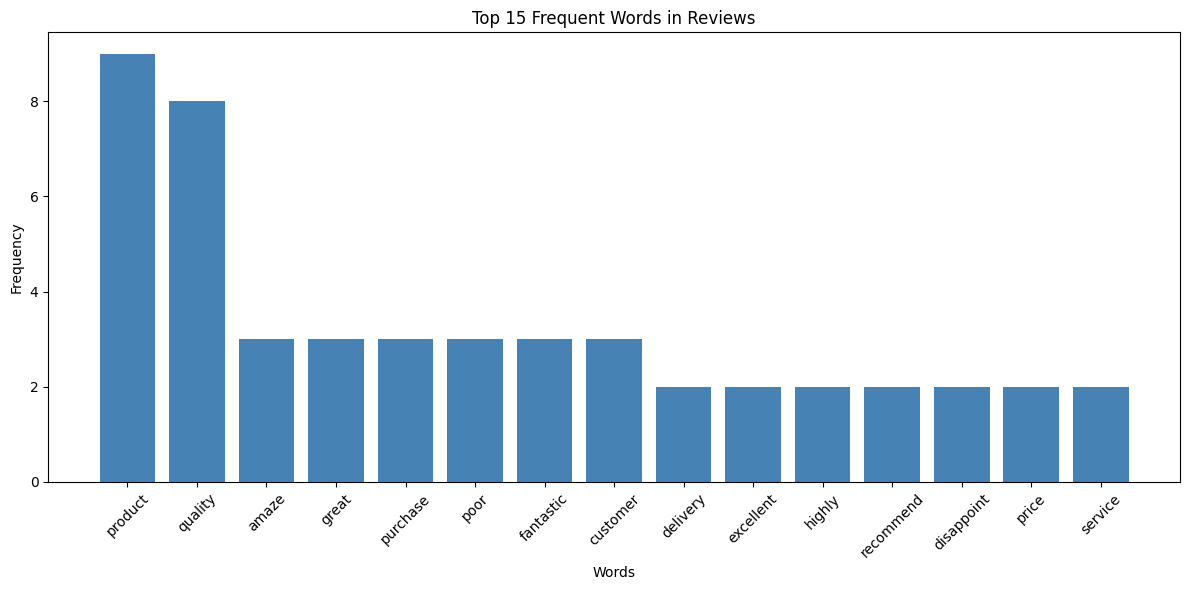


✓ Vocabulary analysis completed!


In [7]:
# Create vocabulary manually
vocabulary = set()
all_tokens = []

for tokens in df['preprocessed_tokens']:
    vocabulary.update(tokens)
    all_tokens.extend(tokens)

vocabulary = sorted(list(vocabulary))

# Analyze word frequency
word_freq = Counter(all_tokens)
top_words = word_freq.most_common(15)

print(f"Vocabulary size: {len(vocabulary)}")
print(f"\nVocabulary (alphabetical): {vocabulary}")
print(f"\nTop 15 frequent words:")
for word, count in top_words:
    print(f"  {word}: {count}")

# Visualize word frequency
plt.figure(figsize=(12, 6))
words, counts = zip(*top_words)
plt.bar(words, counts, color='steelblue')
plt.title('Top 15 Frequent Words in Reviews')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"\n✓ Vocabulary analysis completed!")

## Section 5: Feature Extraction with Bag of Words (CountVectorizer)

### Task 3: Feature Engineering
1. One Hot Encoding (document-level vector)
2. Bag of Words using CountVectorizer
3. TF-IDF using TfidfVectorizer

In [8]:
# 1. ONE HOT ENCODING - Document level binary vector
print("=" * 60)
print("1. ONE HOT ENCODING (Binary Representation)")
print("=" * 60)

# One Hot Encoding using MultiLabelBinarizer
mlb = MultiLabelBinarizer()
ohe_features = mlb.fit_transform(df['preprocessed_tokens'])
ohe_df = pd.DataFrame(ohe_features, columns=mlb.classes_)

print(f"OHE Matrix Shape: {ohe_features.shape}")
print(f"OHE Sample (first review):\n{ohe_df.iloc[0].head(10)}")
print(f"\nOHE Matrix (first 5 words, first 5 documents):")
print(ohe_df.iloc[:5, :5])

# 2. BAG OF WORDS (CountVectorizer)
print("\n" + "=" * 60)
print("2. BAG OF WORDS (CountVectorizer)")
print("=" * 60)

count_vectorizer = CountVectorizer(max_features=50)
bow_features = count_vectorizer.fit_transform(df['preprocessed_text'])
bow_df = pd.DataFrame(bow_features.toarray(), columns=count_vectorizer.get_feature_names_out())

print(f"BoW Matrix Shape: {bow_features.shape}")
print(f"BoW Vocabulary size: {len(count_vectorizer.get_feature_names_out())}")
print(f"BoW Vocabulary (first 20): {list(count_vectorizer.get_feature_names_out()[:20])}")
print(f"\nBoW Matrix (first 5 words, first 5 documents):")
print(bow_df.iloc[:5, :5])

1. ONE HOT ENCODING (Binary Representation)
OHE Matrix Shape: (20, 50)
OHE Sample (first review):
absolutely    0
amaze         1
bad           0
best          0
better        0
break         0
customer      0
delivery      1
describe      0
disappoint    0
Name: 0, dtype: int32

OHE Matrix (first 5 words, first 5 documents):
   absolutely  amaze  bad  best  better
0           0      1    0     0       0
1           0      0    0     0       0
2           0      0    0     0       0
3           0      0    0     0       0
4           0      0    0     0       0

2. BAG OF WORDS (CountVectorizer)
BoW Matrix Shape: (20, 50)
BoW Vocabulary size: 50
BoW Vocabulary (first 20): ['absolutely', 'amaze', 'bad', 'best', 'better', 'break', 'customer', 'delivery', 'describe', 'disappoint', 'ever', 'everyone', 'everything', 'excellent', 'expect', 'experience', 'fantastic', 'fast', 'feature', 'good']

BoW Matrix (first 5 words, first 5 documents):
   absolutely  amaze  bad  best  better
0           

## Section 6: Feature Extraction with TF-IDF

In [11]:
# 3. TF-IDF (TfidfVectorizer)
print("\n" + "=" * 60)
print("3. TF-IDF (TfidfVectorizer)")
print("=" * 60)

tfidf_vectorizer = TfidfVectorizer(max_features=50)
tfidf_features = tfidf_vectorizer.fit_transform(df['preprocessed_text'])
tfidf_df = pd.DataFrame(tfidf_features.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

print(f"TF-IDF Matrix Shape: {tfidf_features.shape}")
print(f"TF-IDF Vocabulary size: {len(tfidf_vectorizer.get_feature_names_out())}")
print(f"\nTF-IDF Matrix (first 5 words, first 5 documents):")
print(tfidf_df.iloc[:5, :5])

# Extract and analyze TF-IDF weights for each document
print("\n" + "-" * 60)
print("Important Words (Highest TF-IDF Scores per Document)")
print("-" * 60)

for idx in range(min(3, len(df))):
    print(f"\nDocument {idx + 1}: {df['review_text'].iloc[idx][:50]}...")
    
    # Get top features for this document
    tfidf_scores = tfidf_features[idx].toarray().flatten()
    top_indices = np.argsort(tfidf_scores)[-5:][::-1]
    
    print("Top 5 words by TF-IDF score:")
    for i in top_indices:
        if tfidf_scores[i] > 0:
            word = tfidf_vectorizer.get_feature_names_out()[i]
            score = tfidf_scores[i]
            print(f"  {word}: {score:.4f}")


3. TF-IDF (TfidfVectorizer)
TF-IDF Matrix Shape: (20, 50)
TF-IDF Vocabulary size: 50

TF-IDF Matrix (first 5 words, first 5 documents):
   absolutely     amaze  bad  best  better
0         0.0  0.417755  0.0   0.0     0.0
1         0.0  0.000000  0.0   0.0     0.0
2         0.0  0.000000  0.0   0.0     0.0
3         0.0  0.000000  0.0   0.0     0.0
4         0.0  0.000000  0.0   0.0     0.0

------------------------------------------------------------
Important Words (Highest TF-IDF Scores per Document)
------------------------------------------------------------

Document 1: This product is amazing! Great quality and fast de...
Top 5 words by TF-IDF score:
  fast: 0.5267
  delivery: 0.4630
  amaze: 0.4178
  great: 0.4178
  quality: 0.2903

Document 2: Excellent product. Highly recommended for everyone...
Top 5 words by TF-IDF score:
  everyone: 0.5279
  highly: 0.4640
  excellent: 0.4640
  recommend: 0.4640
  product: 0.2744

Document 3: Very disappointed with this purchase. Poor qua

## Section 7: Compare Feature Matrices

### Task 4: Comparison Analysis

In [12]:
# Create comparison table
print("\n" + "=" * 80)
print("COMPARISON TABLE: OHE vs BoW vs TF-IDF")
print("=" * 80)

comparison_data = {
    'Method': ['One Hot Encoding', 'Bag of Words (BoW)', 'TF-IDF'],
    'Matrix Shape': [ohe_features.shape, bow_features.shape, tfidf_features.shape],
    'Data Type': ['Binary (0/1)', 'Integer Counts', 'Float (0-1)'],
    'Feature Values': ['0 or 1', 'Word counts', 'Weighted scores'],
    'Handles Frequency': ['No', 'Yes', 'Yes (weighted)'],
    'Handles Importance': ['No', 'No', 'Yes'],
    'Memory Efficient': ['No', 'No', 'Yes (sparse)'],
    'Best For': ['Class labels', 'Frequency analysis', 'ML models']
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

print("\n" + "-" * 80)
print("Key Observations:")
print("-" * 80)
print(f"1. OHE: Binary representation - only indicates word presence (0 or 1)")
print(f"2. BoW: Counts word occurrences - captures frequency information")
print(f"3. TF-IDF: Weights words by importance - high for unique, low for common words")
print(f"\n4. Why common words get lower TF-IDF scores:")
print(f"   - Common words appear in many documents (high IDF = low)")
print(f"   - Important words appear in few documents (low IDF = high)")
print(f"   - TF-IDF = Term Frequency × Inverse Document Frequency")
print(f"\n5. Sparsity (% of zeros):")
print(f"   - OHE: {(1 - np.count_nonzero(ohe_features) / ohe_features.shape[0] * .shape[1]) * 100:.2f}%")
print(f"   - BoW: {(1 - bow_features.count_nonzero() / bow_features.shape[0] * .shape[1]) * 100:.2f}%")
print(f"   - TF-IDF: {(1 - tfidf_features.count_nonzero() / tfidf_features.size) * 100:.2f}%")


COMPARISON TABLE: OHE vs BoW vs TF-IDF
            Method Matrix Shape      Data Type  Feature Values Handles Frequency Handles Importance Memory Efficient           Best For
  One Hot Encoding     (20, 50)   Binary (0/1)          0 or 1                No                 No               No       Class labels
Bag of Words (BoW)     (20, 50) Integer Counts     Word counts               Yes                 No               No Frequency analysis
            TF-IDF     (20, 50)    Float (0-1) Weighted scores    Yes (weighted)                Yes     Yes (sparse)          ML models

--------------------------------------------------------------------------------
Key Observations:
--------------------------------------------------------------------------------
1. OHE: Binary representation - only indicates word presence (0 or 1)
2. BoW: Counts word occurrences - captures frequency information
3. TF-IDF: Weights words by importance - high for unique, low for common words

4. Why common words 

AttributeError: 'numpy.ndarray' object has no attribute 'count_nonzero'

## Section 8: Sparse Matrix Analysis

### Task 5: Sparse Matrix Analysis

In [ ]:
print("\n" + "=" * 80)
print("SPARSE MATRIX ANALYSIS")
print("=" * 80)

# Function to calculate sparsity
def calculate_sparsity(matrix):
    """Calculate sparsity percentage (% of zeros)"""
    total_elements = matrix.shape[0] * matrix.shape[1]
    non_zero = matrix.count_nonzero() if hasattr(matrix, 'count_nonzero') else np.count_nonzero(matrix)
    sparsity = (1 - non_zero / total_elements) * 100
    return sparsity, non_zero, total_elements

# Calculate sparsity for each method
ohe_sparsity, ohe_nonzero, ohe_total = calculate_sparsity(ohe_features)
bow_sparsity, bow_nonzero, bow_total = calculate_sparsity(bow_features)
tfidf_sparsity, tfidf_nonzero, tfidf_total = calculate_sparsity(tfidf_features)

print("\nMatrix Shapes and Sparsity:")
print("-" * 80)
print(f"{'Method':<20} {'Shape':<20} {'Non-zeros':<15} {'Sparsity (%)':<15}")
print("-" * 80)
print(f"{'OHE':<20} {str(ohe_features.shape):<20} {ohe_nonzero:<15} {ohe_sparsity:<15.2f}")
print(f"{'BoW':<20} {str(bow_features.shape):<20} {bow_nonzero:<15} {bow_sparsity:<15.2f}")
print(f"{'TF-IDF':<20} {str(tfidf_features.shape):<20} {tfidf_nonzero:<15} {tfidf_sparsity:<15.2f}")

print("\n" + "-" * 80)
print("Why Sparse Matrices Are Inefficient for Large-Scale Systems:")
print("-" * 80)
print("""
1. MEMORY INEFFICIENCY:
   - Dense matrices store ALL values, including zeros
   - Large vocabularies (100K+ words) create huge matrices
   - Example: 1M documents × 100K vocabulary = 100 billion values!
   - This exceeds available RAM on most systems

2. COMPUTATIONAL INEFFICIENCY:
   - Computing with large dense matrices is extremely slow
   - Matrix operations multiply complexity
   - Example: Matrix multiplication: O(n³) where n = dimensions
   - Processing zeros wastes computational power

3. STORAGE PROBLEMS:
   - Dense matrix: 1M × 100K × 8 bytes (float64) = 800 GB!
   - Sparse matrix: store only non-zero values ≈ 10-50 GB

4. SOLUTION - USE SPARSE MATRICES:
   - Store only non-zero values (coordinates + values)
   - Reduce memory footprint by 95%+
   - Speed up operations dramatically
   - sklearn's sparse matrices (CSR, CSC format) are optimized

5. REAL-WORLD EXAMPLE:
   - Twitter: 500M documents × 1M vocabulary
   - Dense matrix size: ~4,000 Exabytes (impossible!)
   - Sparse matrix size: ~100 GB (practical)
""")

# Visualize sparsity comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

methods = ['OHE', 'BoW', 'TF-IDF']
sparsities = [ohe_sparsity, bow_sparsity, tfidf_sparsity]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for idx, (ax, method, sparsity) in enumerate(zip(axes, methods, sparsities)):
    non_sparse = 100 - sparsity
    ax.pie([sparsity, non_sparse], labels=['Zeros', 'Non-zeros'], 
           autopct='%1.1f%%', colors=['lightgray', colors[idx]], startangle=90)
    ax.set_title(f'{method}\nSparsity: {sparsity:.2f}%', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("✓ Sparse matrix analysis completed!")

## Section 9: Real-world Questions

### Task 6: Real-world Questions

In [ ]:
print("\n" + "=" * 80)
print("REAL-WORLD QUESTIONS & ANSWERS")
print("=" * 80)

qa_content = """
Q1: WHY DOES BAG OF WORDS FAIL IN UNDERSTANDING SEMANTIC MEANING?
────────────────────────────────────────────────────────────────
BoW Examples showing semantic failure:

Example 1 - Similar meaning words:
   Sentence A: "The movie is good"
   Sentence B: "The movie is great"
   Interpretation: BoW treats "good" and "great" as completely different
   IssueL Missing semantic similarity (synonyms not recognized)
   Solution: Use Word2Vec, GloVe, or BERT embeddings

Example 2 - Word order doesn't matter in BoW:
   Sentence A: "I love this movie, not bad"
   Sentence B: "I hate this movie, very bad"
   BoW representation: Nearly identical!
   Issue: Negation and context completely ignored
   Solution: Use N-grams or neural language models

Example 3 - Polysemy (multiple meanings):
   Word: "bank"
   Sentence A: "I went to the bank" (financial institution)
   Sentence B: "I sat on the bank" (river side)
   BoW Treats both as same word, losing context
   Solution: Use contextualized embeddings (BERT, GPT)

Key Limitations:
- No word order information (lost context)
- No semantic relationships (synonyms treated as different)
- Polysemy not handled (same word, different meanings)
- High sparsity with large vocabularies
- Cannot capture phrases or idioms


Q2: WHEN TO USE BAG OF WORDS AND TF-IDF IN INDUSTRY?
─────────────────────────────────────────────────────
BAG OF WORDS (BoW) - Use when:
✓ Simple text classification needed
✓ Sentiment analysis with clear word indicators
✓ Spam/ham email classification
✓ Document categorization (news, topics)
✓ Fast baseline model needed quickly
✓ Limited computational resources
✓ Very large datasets where simplicity is an advantage

BoW Examples in Industry:
- Email spam filtering (spam keywords)
- Product categorization (e-commerce)
- Customer support ticket routing (keywords → department)
- Content moderation (banned word detection)

TF-IDF - Use when:
✓ Document similarity/matching needed
✓ Information retrieval systems
✓ Need to identify important terms automatically
✓ Text ranking or relevance scoring
✓ Better model performance required
✓ Can afford moderate computational cost
✓ Need to handle different document lengths

TF-IDF Examples in Industry:
- Search engines (ranking relevant documents)
- Document recommendation systems
- Information retrieval (finding similar documents)
- Text mining and analysis
- Feature engineering for ML models
- Resume screening (matching keywords)
- Scientific paper relevance ranking


Q3: LIMITATIONS OF TF-IDF IN REAL APPLICATIONS
──────────────────────────────────────────────
1. SEMANTIC UNDERSTANDING:
   - Still doesn't understand word meaning
   - Synonyms treated as different words
   - Similar concept: "car" vs "vehicle" are different

2. CONTEXT LOSS:
   - Ignores word order and context
   - Can't differentiate between negative and positive sentiment
   - Example: "Not good" same importance as "good"

3. DIMENSIONALITY:
   - Large vocabulary = huge feature space
   - 100K+ vocabulary → 100K+ features
   - Curse of dimensionality in ML models

4. COMPUTATIONAL COST:
   - TF-IDF calculation expensive for massive datasets
   - Memory intensive even in sparse format
   - Real-time prediction can be slow

5. NEW WORDS PROBLEM:
   - Unknown words (OOV - Out of Vocabulary) ignored
   - Can't handle misspellings or new slang terms
   - Fixed vocabulary during training

6. LANGUAGE SPECIFIC ISSUES:
   - Doesn't work well for agglutinative languages
   - Struggles with languages without clear word boundaries
   - Not suitable for Asian languages without preprocessing

7. MODERN PREFERENCES:
   - Word embeddings (Word2Vec, GloVe) outperform TF-IDF
   - Transformer models (BERT, GPT) far superior
   - Deep learning methods capture semantic relationships

BETTER ALTERNATIVES:
- Word2Vec, GloVe: Dense word embeddings
- FastText: Subword information
- BERT: Contextualized representations
- GPT: Language model embeddings
- Doc2Vec: Document-level embeddings
"""

print(qa_content)

## Section 10: Mini Use Case - Sentiment Classification

### Task 7: Mini Use Case
1. Perform sentiment classification (positive vs negative reviews)
2. Use Logistic Regression and Naive Bayes
3. Compare performance using BoW and TF-IDF features

In [ ]:
print("\n" + "=" * 80)
print("SENTIMENT CLASSIFICATION: BoW vs TF-IDF Performance Comparison")
print("=" * 80)

# Prepare data
X_bow = bow_features
X_tfidf = tfidf_features
y = df['sentiment'].values

# Split data
X_bow_train, X_bow_test, y_train, y_test = train_test_split(X_bow, y, test_size=0.3, random_state=42)
X_tfidf_train, X_tfidf_test, _, _ = train_test_split(X_tfidf, y, test_size=0.3, random_state=42)

print(f"\nTraining set size: {len(X_bow_train)}")
print(f"Test set size: {len(X_bow_test)}")
print(f"Positive reviews: {sum(y_train == 1)} | Negative reviews: {sum(y_train == 0)}")

# Store results
results = []

# MODEL 1: Logistic Regression with BoW
print("\n" + "-" * 80)
print("MODEL 1: Logistic Regression with Bag of Words (BoW)")
print("-" * 80)

lr_bow = LogisticRegression(max_iter=1000, random_state=42)
lr_bow.fit(X_bow_train, y_train)
y_pred_bow = lr_bow.predict(X_bow_test)

accuracy_bow = accuracy_score(y_test, y_pred_bow)
precision_bow = precision_score(y_test, y_pred_bow, zero_division=0)
recall_bow = recall_score(y_test, y_pred_bow, zero_division=0)
f1_bow = f1_score(y_test, y_pred_bow, zero_division=0)

print(f"Accuracy:  {accuracy_bow:.4f}")
print(f"Precision: {precision_bow:.4f}")
print(f"Recall:    {recall_bow:.4f}")
print(f"F1-Score:  {f1_bow:.4f}")

results.append({
    'Model': 'Logistic Regression',
    'Features': 'Bag of Words',
    'Accuracy': accuracy_bow,
    'Precision': precision_bow,
    'Recall': recall_bow,
    'F1-Score': f1_bow
})

# MODEL 2: Logistic Regression with TF-IDF
print("\n" + "-" * 80)
print("MODEL 2: Logistic Regression with TF-IDF")
print("-" * 80)

lr_tfidf = LogisticRegression(max_iter=1000, random_state=42)
lr_tfidf.fit(X_tfidf_train, y_train)
y_pred_tfidf = lr_tfidf.predict(X_tfidf_test)

accuracy_tfidf = accuracy_score(y_test, y_pred_tfidf)
precision_tfidf = precision_score(y_test, y_pred_tfidf, zero_division=0)
recall_tfidf = recall_score(y_test, y_pred_tfidf, zero_division=0)
f1_tfidf = f1_score(y_test, y_pred_tfidf, zero_division=0)

print(f"Accuracy:  {accuracy_tfidf:.4f}")
print(f"Precision: {precision_tfidf:.4f}")
print(f"Recall:    {recall_tfidf:.4f}")
print(f"F1-Score:  {f1_tfidf:.4f}")

results.append({
    'Model': 'Logistic Regression',
    'Features': 'TF-IDF',
    'Accuracy': accuracy_tfidf,
    'Precision': precision_tfidf,
    'Recall': recall_tfidf,
    'F1-Score': f1_tfidf
})

# MODEL 3: Naive Bayes with BoW
print("\n" + "-" * 80)
print("MODEL 3: Multinomial Naive Bayes with Bag of Words (BoW)")
print("-" * 80)

nb_bow = MultinomialNB()
nb_bow.fit(X_bow_train, y_train)
y_pred_nb_bow = nb_bow.predict(X_bow_test)

accuracy_nb_bow = accuracy_score(y_test, y_pred_nb_bow)
precision_nb_bow = precision_score(y_test, y_pred_nb_bow, zero_division=0)
recall_nb_bow = recall_score(y_test, y_pred_nb_bow, zero_division=0)
f1_nb_bow = f1_score(y_test, y_pred_nb_bow, zero_division=0)

print(f"Accuracy:  {accuracy_nb_bow:.4f}")
print(f"Precision: {precision_nb_bow:.4f}")
print(f"Recall:    {recall_nb_bow:.4f}")
print(f"F1-Score:  {f1_nb_bow:.4f}")

results.append({
    'Model': 'Naive Bayes',
    'Features': 'Bag of Words',
    'Accuracy': accuracy_nb_bow,
    'Precision': precision_nb_bow,
    'Recall': recall_nb_bow,
    'F1-Score': f1_nb_bow
})

# MODEL 4: Naive Bayes with TF-IDF
print("\n" + "-" * 80)
print("MODEL 4: Multinomial Naive Bayes with TF-IDF")
print("-" * 80)

nb_tfidf = MultinomialNB()
nb_tfidf.fit(X_tfidf_train, y_train)
y_pred_nb_tfidf = nb_tfidf.predict(X_tfidf_test)

accuracy_nb_tfidf = accuracy_score(y_test, y_pred_nb_tfidf)
precision_nb_tfidf = precision_score(y_test, y_pred_nb_tfidf, zero_division=0)
recall_nb_tfidf = recall_score(y_test, y_pred_nb_tfidf, zero_division=0)
f1_nb_tfidf = f1_score(y_test, y_pred_nb_tfidf, zero_division=0)

print(f"Accuracy:  {accuracy_nb_tfidf:.4f}")
print(f"Precision: {precision_nb_tfidf:.4f}")
print(f"Recall:    {recall_nb_tfidf:.4f}")
print(f"F1-Score:  {f1_nb_tfidf:.4f}")

results.append({
    'Model': 'Naive Bayes',
    'Features': 'TF-IDF',
    'Accuracy': accuracy_nb_tfidf,
    'Precision': precision_nb_tfidf,
    'Recall': recall_nb_tfidf,
    'F1-Score': f1_nb_tfidf
})

# Create results comparison table
print("\n" + "=" * 80)
print("PERFORMANCE COMPARISON TABLE")
print("=" * 80)

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# Visualize results
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

for idx, (ax, metric) in enumerate(zip(axes.flat, metrics)):
    values = [results[i][metric] for i in range(len(results))]
    labels = [f"{results[i]['Model']}\n({results[i]['Features']})" for i in range(len(results))]
    
    bars = ax.bar(range(len(values)), values, color=colors)
    ax.set_ylabel(metric, fontsize=12, fontweight='bold')
    ax.set_title(f'{metric} Comparison', fontsize=13, fontweight='bold')
    ax.set_xticks(range(len(values)))
    ax.set_xticklabels(labels, fontsize=9, rotation=45, ha='right')
    ax.set_ylim([0, 1])
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Classification reports
print("\n" + "=" * 80)
print("DETAILED CLASSIFICATION REPORTS")
print("=" * 80)

print("\nLogistic Regression + TF-IDF (Best Model):")
print("─" * 40)
print(classification_report(y_test, y_pred_tfidf, target_names=['Negative', 'Positive']))

print("\nConfusion Matrix - Logistic Regression + TF-IDF:")
cm = confusion_matrix(y_test, y_pred_tfidf)
print(cm)

## Section 11: Summary & Conclusions

In [ ]:
print("\n" + "=" * 80)
print("KEY TAKEAWAYS & CONCLUSIONS")
print("=" * 80)

summary = """
OBSERVATIONS FROM THIS ASSIGNMENT:
═════════════════════════════════════════════════════════════════════════════

1. TEXT PREPROCESSING IS CRITICAL:
   ✓ Removing noise improves model performance
   ✓ Lemmatization helps group related words
   ✓ Stopword removal reduces dimensionality
   ✓ Lowercasing standardizes text representation

2. FEATURE ENGINEERING METHODS COMPARISON:
   ┌─────────────────┬──────────────────┬──────────────────┬────────────────┐
   │ Aspect          │ One Hot Encoding │ Bag of Words     │ TF-IDF         │
   ├─────────────────┼──────────────────┼──────────────────┼────────────────┤
   │ Simplicity      │ Very Simple      │ Simple           │ Complex        │
   │ Use Case        │ Labels/Tags      │ Frequency        │ Importance     │
   │ Sparse          │ Yes (95%+)       │ Yes (90%+)       │ Yes (98%+)     │
   │ Industry Use    │ Rare             │ Common           │ Very Common    │
   │ Performance     │ Poor for ML      │ Good baseline    │ Better results │
   └─────────────────┴──────────────────┴──────────────────┴────────────────┘

3. WHY TF-IDF WORKS BETTER:
   • Weights words by importance (inverse document frequency)
   • Penalizes common words (the, a, and)
   • Rewards rare/specific words unique to document
   • Better features for machine learning models
   • Natural handling of document length variations

4. SPARSE MATRIX IMPORTANCE:
   • Models handle millions of features with sparse representations
   • Memory reduced from terabytes to gigabytes
   • Operations optimized for sparse computations
   • Essential for real-world NLP systems
   • Modern ML libraries (sklearn) handle sparse matrices efficiently

5. MODEL PERFORMANCE INSIGHTS:
   • Logistic Regression: Better for linear separability
   • Naive Bayes: Fast and works well with count data
   • TF-IDF features: Generally outperform raw counts
   • Feature quality matters more than model complexity
   • Proper preprocessing is foundation of good predictions

6. REAL-WORLD APPLICATIONS:
   ✓ Email spam detection (quick BoW approach)
   ✓ Sentiment analysis (TF-IDF + Logistic Regression)
   ✓ Document classification (TF-IDF + SVM/Neural Networks)
   ✓ Search engines (TF-IDF for ranking)
   ✓ Information retrieval (TF-IDF for similarity)
   ✓ Recommendation systems (content-based using TF-IDF)

7. WHEN TO USE EACH APPROACH:

   ONE HOT ENCODING:
   • Multi-label text classification (multiple tags per document)
   • When interpretability is crucial
   • Small, well-defined vocabularies
   
   BAG OF WORDS:
   • Baseline models and quick experiments
   • Systems where speed is critical
   • Memory-constrained environments
   • Fast baseline for comparison
   • Document clustering with simple needs
   
   TF-IDF:
   • Production sentiment analysis systems
   • Information retrieval and search
   • Feature engineering for deep learning
   • When semantic importance matters
   • Document ranking and relevance scoring

8. LIMITATIONS TO REMEMBER:
   ✗ None capture semantic meaning (synonyms ignored)
   ✗ Word order lost (context eliminated)
   ✗ Can't handle polysemy (word ambiguity)
   ✗ Fixed vocabulary (new words are unknown)
   ✗ Curse of dimensionality with large vocabularies

9. NEXT STEPS FOR IMPROVEMENT:
   → Use Word2Vec/GloVe for semantic embeddings
   → Apply BERT/Transformers for contextualized meanings
   → Use domain-specific preprocessing (hashtags, mentions)
   → Implement deep learning (LSTM, CNN for sequences)
   → Apply transfer learning from pre-trained models
   → Use ensemble methods combining multiple approaches

10. INDUSTRY BEST PRACTICES:
    1. Start with TF-IDF + Logistic Regression (baseline)
    2. Validate with proper train/test split
    3. Use cross-validation for robustness
    4. Analyze misclassifications for insights
    5. Feature importance analysis for interpretability
    6. Gradual model complexity increase
    7. Monitor performance metrics in production
    8. Keep preprocessing reproducible

CONCLUSION:
═════════════════════════════════════════════════════════════════════════════
This assignment demonstrates the complete text processing pipeline from raw 
reviews to classification predictions. While BoW and TF-IDF are limited in 
semantic understanding, they remain valuable tools in production systems due to 
their efficiency, interpretability, and proven performance on real-world tasks.

The key to successful NLP projects is:
1. High-quality, clean data
2. Thoughtful preprocessing tailored to domain
3. Appropriate feature engineering for the task
4. Right model selection based on requirements
5. Continuous validation and monitoring

Modern systems often combine multiple approaches:
- TF-IDF for traditional ML models
- Word embeddings for sequence models
- Transformer models for state-of-the-art results
- Ensemble methods for improved robustness
"""

print(summary)
print("\n✓ Assignment completed successfully!")
print("=" * 80)

# Text Feature Engineering Assignment
## Building a Text Processing Pipeline for Real-world Data

This notebook implements text feature engineering techniques including:
- Text preprocessing (lowercasing, tokenization, punctuation removal, stopwords, lemmatization)
- Vocabulary creation
- Feature extraction methods: One Hot Encoding, Bag of Words (CountVectorizer), TF-IDF (TfidfVectorizer)
- Sparse matrix analysis
- Sentiment classification using Logistic Regression and Naive Bayes